In [5]:
#Gaussian Channel as DataSet

import pandas as pd
import numpy as np

# =========================
# Parâmetros
# =========================
V_mod = 1
excess_noise = 0.02
rho = 0.0
tau = 0.2
realizacoes = 1000

mu = np.array([0, 0])

# =========================
# Alice ~ N(0, I)
# =========================
samples_Alice = np.random.multivariate_normal(mu, np.eye(2), realizacoes)

Alice_df = pd.DataFrame(samples_Alice, columns=['P', 'Q'])

# =========================
# Ruído (heterodyne)
# =========================
sigma_x2 = (1 + (excess_noise / 2)) / ((tau / 2) * V_mod)

cov_y = np.array([
    [sigma_x2, sigma_x2 * rho],
    [sigma_x2 * rho, sigma_x2]
])

ruido = np.random.multivariate_normal(mu, cov_y, realizacoes)

# =========================
# Bob
# =========================
samples_Bob = samples_Alice + ruido
Bob_df = pd.DataFrame(samples_Bob, columns=['P', 'Q'])



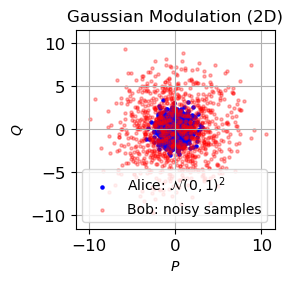

In [7]:
# =========================
# Plot - Alice and Bob samples
# =========================

import matplotlib.pyplot as plt 



plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 10,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "figure.figsize": (3, 3)
})

fig, ax = plt.subplots()

# Alice
ax.scatter(
    samples_Alice[:, 0],
    samples_Alice[:, 1],
    s=5,
    color='blue',
    #alpha=0.5,
    label=r'Alice: $\mathcal{N}(0,1)^2$'
)

# Bob
ax.scatter(
    samples_Bob[:, 0],
    samples_Bob[:, 1],
    s=5,
    color='red',
    alpha=0.3,
    label='Bob: noisy samples'
)

# Estética
ax.set_xlabel(r'$P$')
ax.set_ylabel(r'$Q$')
ax.set_title('Gaussian Modulation (2D)')
ax.legend()
ax.grid(True)
ax.set_aspect('equal', adjustable='box')

# Limites simétricos
lim = np.max(np.abs(samples_Bob)) * 1.1
ax.set_xlim([-lim, lim])
ax.set_ylim([-lim, lim])

plt.tight_layout()
"""sns.kdeplot(
    x=samples_Bob[:,0],
    y=samples_Bob[:,1],
    levels=10,
    linewidths=1
)"""

plt.savefig("Bidimensional_gaussian.png", dpi=300)
plt.show()


In [12]:
# Generating DataFrames with SNRs
import numpy as np
import pandas as pd

V_mod_tilde = 1
excess_noise=0.02
tau = np.arange(0.02, 0.28, 0.02, dtype=np.float32) #transmitância (40 pontos)
D = -np.log10(tau)*(10/0.2) # tau = 10^(-alpha*d/10)
V_mod = 4 * V_mod_tilde
nbits = 4

SNR_list = (tau * (V_mod) / (1 + excess_noise)).astype(np.float32) #homodyne
#SNR_list = ((tau/2) * (V_mod) / (1 + (excess_noise/2))).astype(np.float32) #heterodyne
SNRdB_list = (10 * np.log10(SNR_list))

# importing results of 4 channels
Capacity_P = np.loadtxt('Capacity_P_heterodyne.txt', dtype=np.float32)
Capacity_Q = np.loadtxt('Capacity_Q_heterodyne.txt', dtype=np.float32)
Pe_P = np.loadtxt('PE_P_heterodyne.txt', dtype = np.float32)
Pe_Q = np.loadtxt('PE_Q_heterodyne.txt', dtype = np.float32)

channels = ['ch1', 'ch2', 'ch3', 'ch4']

rows = []

for snr in range(len(SNRdB_list)):
    for channel in range(nbits):
        rows.append([SNRdB_list[snr], 'P', channel+1, Pe_P[snr, channel], Capacity_P[snr,channel]])
        rows.append([SNRdB_list[snr], 'Q', channel+1, Pe_Q[snr, channel], Capacity_Q[snr,channel]])
        
df = pd.DataFrame(rows, columns=["SNR", "Quadratura", "Channel", "Pe", "C"]) #where C is the channel capacity
print(df.head())



         SNR Quadratura  Channel        Pe         C
0 -11.055101          P        1  0.437383  0.011407
1 -11.055101          Q        1  0.437778  0.011287
2 -11.055101          P        2  0.478510  0.001404
3 -11.055101          Q        2  0.477390  0.001548
4 -11.055101          P        3  0.492544  0.000220


In [13]:
print(f"Info: {df.info()}")
print(f"Description: {df.describe()}")
print(f"Nulo? {df.isnull().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   SNR         104 non-null    float32
 1   Quadratura  104 non-null    object 
 2   Channel     104 non-null    int64  
 3   Pe          104 non-null    float32
 4   C           104 non-null    float32
dtypes: float32(3), int64(1), object(1)
memory usage: 3.0+ KB
Info: None
Description:               SNR     Channel          Pe           C
count  104.000000  104.000000  104.000000  104.000000
mean    -3.521040    2.500000    0.441401    0.019959
std      3.209318    1.123448    0.058094    0.032444
min    -11.055101    1.000000    0.301709    0.000081
25%     -5.034502    1.750000    0.422324    0.000614
50%     -2.604121    2.500000    0.467949    0.003040
75%     -1.055102    3.250000    0.486245    0.017567
max      0.084331    4.000000    0.498015    0.116698
Nulo? SNR           0
Quadratura    0

In [15]:
assert (df["Pe"] >= 0).all() and (df["Pe"] <= 0.5).all()
assert (df["C"] >= 0).all()

df_group = df.groupby(['SNR', 'Quadratura']).agg({
    'Pe': ['mean','std','min','max'],
    'C': ['mean','std']
}).reset_index

print(df_group)

<bound method DataFrame.reset_index of                              Pe                                       C  \
                           mean       std       min       max      mean   
SNR        Quadratura                                                     
-11.055101 P           0.476305  0.027098  0.437383  0.496784  0.003282   
           Q           0.476313  0.027113  0.437778  0.498015  0.003292   
-8.044802  P           0.466327  0.037807  0.412470  0.496000  0.006465   
           Q           0.466434  0.037865  0.412506  0.496249  0.006454   
-6.283889  P           0.458837  0.045627  0.394000  0.494811  0.009537   
           Q           0.458956  0.045489  0.394092  0.494693  0.009476   
-5.034502  P           0.452717  0.051570  0.379118  0.493062  0.012387   
           Q           0.452851  0.051610  0.379629  0.494237  0.012351   
-4.065402  P           0.447321  0.056810  0.366482  0.492635  0.015224   
           Q           0.447370  0.056574  0.366882  0.491917

         SNR Quadratura  Channel        Pe         C
0 -11.055101          P        1  0.437383  0.011407
2 -11.055101          P        2  0.478510  0.001404
4 -11.055101          P        3  0.492544  0.000220
6 -11.055101          P        4  0.496784  0.000098
8  -8.044802          P        1  0.412470  0.022283
         SNR Quadratura  Channel        Pe         C
1 -11.055101          Q        1  0.437778  0.011287
3 -11.055101          Q        2  0.477390  0.001548
5 -11.055101          Q        3  0.492068  0.000252
7 -11.055101          Q        4  0.498015  0.000081
9  -8.044802          Q        1  0.412506  0.022270


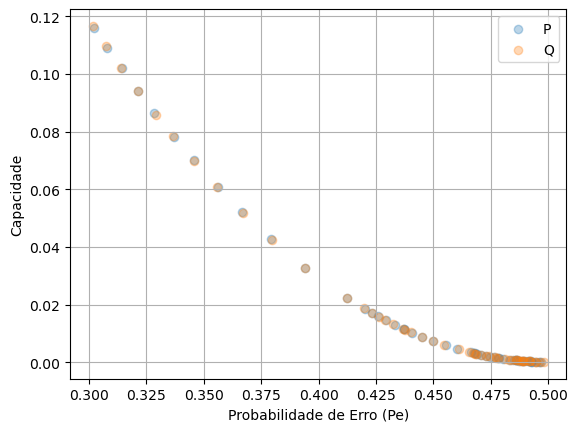

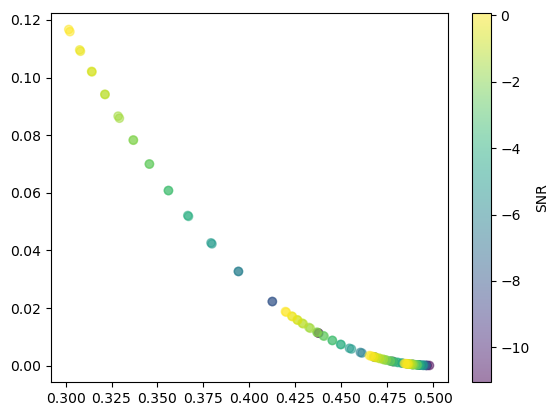

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

### Scatter plot for quadrature (all channels in the same Figure) ####

for quad in ['P', 'Q']:
    subset = df[df["Quadratura"] == quad]
    print(subset.head())
    #print(len(subset))
    
    plt.scatter(subset["Pe"], subset["C"], alpha=0.3, label=quad)

plt.xlabel("Probabilidade de Erro (Pe)")
plt.ylabel("Capacidade")
plt.legend()
plt.grid()
plt.show()

### Here, the same scatter, with a colorbar separating SNRs ####
# it is possible verify different channels, based on SNR variation

plt.scatter(
    df["Pe"],
    df["C"],
    c=df["SNR"],
    cmap="viridis",
    alpha=0.5
)
plt.colorbar(label="SNR")

<Axes: xlabel='Pe', ylabel='C'>

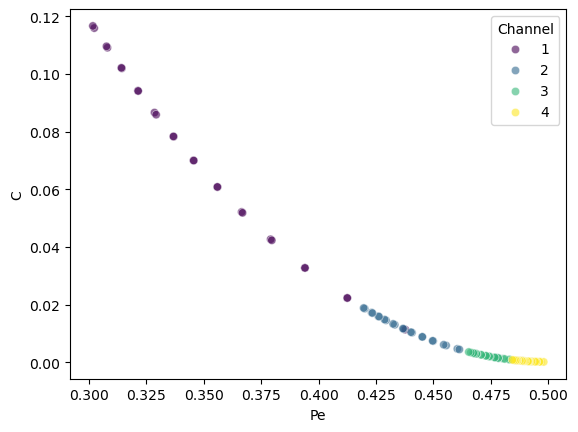

In [42]:
import seaborn as sns

### Here, the same scatter, but each channel presents a different color
sns.scatterplot(
    data=df,
    x="Pe",
    y="C",
    hue="Channel",
    palette="viridis",
    alpha=0.6
)

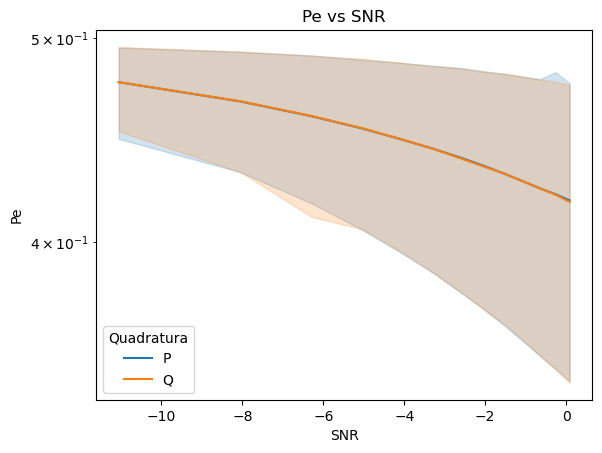

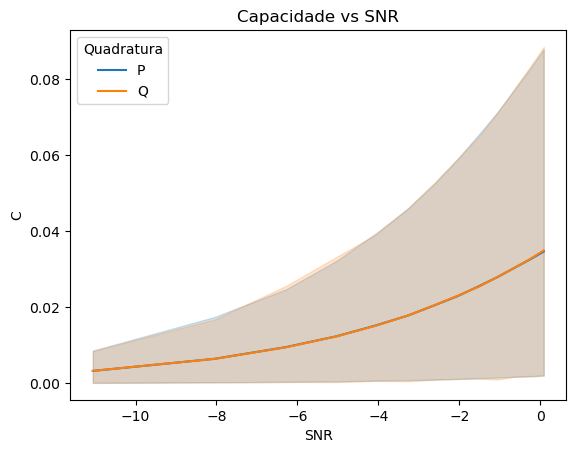

In [54]:
sns.lineplot(data=df, x="SNR", y="Pe", hue="Quadratura", estimator="mean")
plt.yscale("log")
plt.title("Pe vs SNR")
plt.show()

sns.lineplot(data=df, x="SNR", y="C", hue="Quadratura", estimator="mean")
plt.title("Capacidade vs SNR")
plt.show()

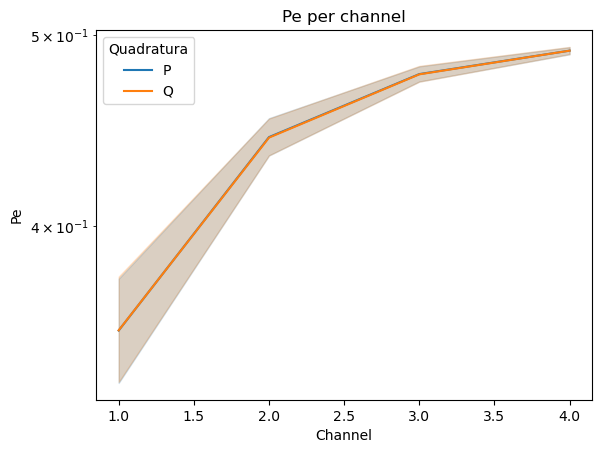

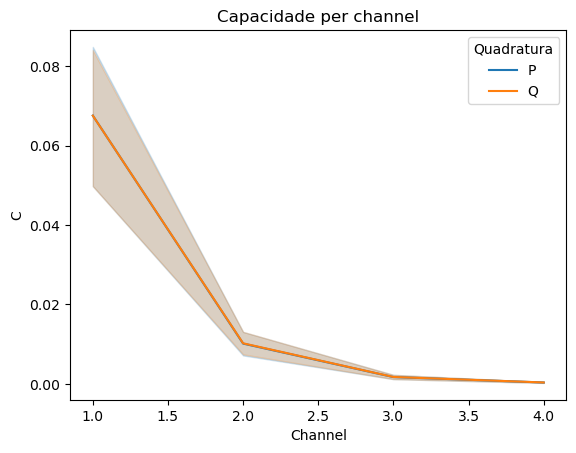

In [57]:
sns.lineplot(data=df, x="Channel", y="Pe", hue="Quadratura")
plt.yscale("log")
plt.title("Pe per channel")
plt.show()

sns.lineplot(data=df, x="Channel", y="C", hue="Quadratura")
plt.title("Capacidade per channel")
plt.show()

          Pe         C
Pe  1.000000 -0.964547
C  -0.964547  1.000000


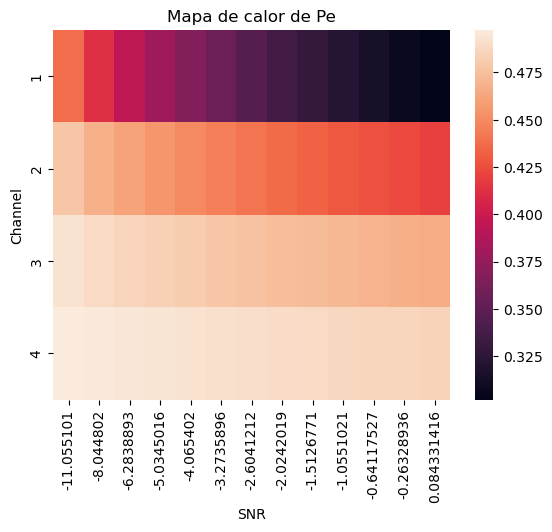

In [77]:
df_corr = df[["Pe", "C"]].corr()
print(df_corr) #as the values are inversely proportional, the correlation is negative

sns.heatmap(df.pivot_table(
    index="Channel",
    columns="SNR",
    values="Pe"
))
plt.title("Mapa de calor de Pe")
plt.show()

In [80]:
df_pivot = df.pivot_table(
    index=["SNR", "Channel"],
    columns="Quadratura",
    values="Pe" #podemos mudar os valores da pivot_table
).reset_index()

df_pivot["delta_Pe"] = df_pivot["P"] - df_pivot["Q"]
print(df_pivot)

Quadratura        SNR  Channel         P         Q  delta_Pe
0          -11.055101        1  0.437383  0.437778 -0.000395
1          -11.055101        2  0.478510  0.477390  0.001120
2          -11.055101        3  0.492544  0.492068  0.000476
3          -11.055101        4  0.496784  0.498015 -0.001232
4           -8.044802        1  0.412470  0.412506 -0.000036
5           -8.044802        2  0.468058  0.468165 -0.000106
6           -8.044802        3  0.488778  0.488816 -0.000038
7           -8.044802        4  0.496000  0.496249 -0.000250
8           -6.283889        1  0.394000  0.394092 -0.000092
9           -6.283889        2  0.460403  0.461290 -0.000887
10          -6.283889        3  0.486133  0.485748  0.000385
11          -6.283889        4  0.494811  0.494693  0.000118
12          -5.034502        1  0.379118  0.379629 -0.000511
13          -5.034502        2  0.455546  0.454455  0.001091
14          -5.034502        3  0.483143  0.483084  0.000059
15          -5.034502   

          SNR Quadratura         C
0  -11.055101          P  0.013130
1  -11.055101          Q  0.013169
2   -8.044802          P  0.025861
3   -8.044802          Q  0.025816
4   -6.283889          P  0.038148
5   -6.283889          Q  0.037905
6   -5.034502          P  0.049548
7   -5.034502          Q  0.049404
8   -4.065402          P  0.060896
9   -4.065402          Q  0.060607
10  -3.273590          P  0.071259
11  -3.273590          Q  0.071322
12  -2.604121          P  0.082232
13  -2.604121          Q  0.082372
14  -2.024202          P  0.092093
15  -2.024202          Q  0.092414
16  -1.512677          P  0.102269
17  -1.512677          Q  0.101800
18  -1.055102          P  0.111829
19  -1.055102          Q  0.111954
20  -0.641175          P  0.121382
21  -0.641175          Q  0.121447
22  -0.263289          P  0.130040
23  -0.263289          Q  0.130452
24   0.084331          P  0.138583
25   0.084331          Q  0.139801


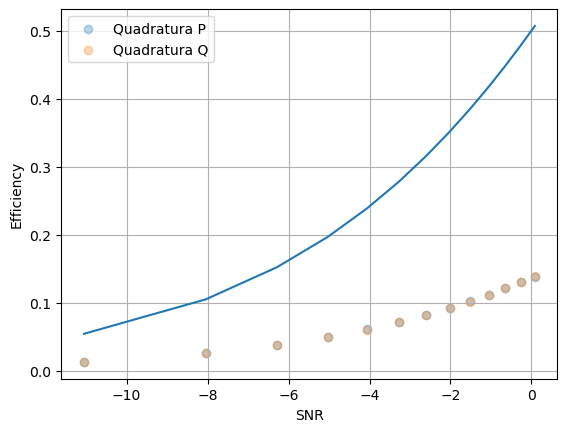

In [105]:
### To calculate the method efficiecy, we use: beta = soma(Pe_i) / capacity_awgn

Capacity_awgn = 1/2 * np.log2(1+SNR_list)

#beta = df.groupby(["SNR", "Quadratura"]).apply(
#    lambda x: x["C"].sum()
#)


beta = df.groupby(["SNR", "Quadratura"])["C"].sum().reset_index()

print(beta)

for quad in beta["Quadratura"].unique():
    subset = beta[beta["Quadratura"] == quad]

    plt.scatter(
        subset["SNR"],
        subset["C"],
        label=f"Quadratura {quad}",
        alpha=0.3
    )

#beta=beta/Capacity_awgn
plt.plot(SNRdB_list, Capacity_awgn)
plt.xlabel("SNR")
plt.ylabel("Efficiency")
plt.legend()
plt.grid()
plt.show()